⏳ Chargement des fichiers IRIS et COM...


C:\Users\vadim\AppData\Local\Temp\ipykernel_32828\3682045556.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_db[col] = final_db[col_iris].fillna(final_db[col_com])


✅ Base de données sauvegardée : 'iris/iris_database_hybride_parfaite.csv'

📥 Chargement pour l'Audit...

🔍 1. INTÉGRITÉ DE LA STRUCTURE
Nombre total de lignes (IRIS) : 49280
Nombre total de colonnes      : 186
Doublons sur le code IRIS     : 0 (Doit être 0)

Répartition par type d'IRIS (H=Habitat, A=Activité, D=Divers, Z=Non découpé) :
TYP_IRIS
Z    33045
H    15005
A      829
D      401
Name: count, dtype: int64

⚙️ 2. VÉRIFICATION DU TYPAGE (Text vs Numérique)
DISP_MED21           : str        ❌ ERREUR (Texte)
DISP_PPAT21          : str        ❌ ERREUR (Texte)
DISP_TP6021          : str        ❌ ERREUR (Texte)
C21_ACT1564_CS3      : float64    ✅ OK
C21_ACT1564_CS6      : float64    ✅ OK
P21_NSCOL15P_SUP5    : float64    ✅ OK

🕳️ 3. TAUX DE COMPLÉTUDE (Le 'Bouchage de trous')
DISP_MED21           : 219 NaN (0.44%)
DISP_PPAT21          : 219 NaN (0.44%)
DISP_TP6021          : 219 NaN (0.44%)
C21_ACT1564_CS3      : 0 NaN (0.00%)
C21_ACT1564_CS6      : 0 NaN (0.00%)
P21_NSCOL15P_SUP5    

C:\Users\vadim\AppData\Local\Temp\ipykernel_32828\3682045556.py:143: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['TOTAL_POP_ESTIM'] = df[colonnes_presentes_pop].sum(axis=1)
C:\Users\vadim\AppData\Local\Temp\ipykernel_32828\3682045556.py:181: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['pct_cadres'] = (df['C21_ACT1564_CS3'] / df['P21_ACT1564']) * 100
C:\Users\vadim\AppData\Local\Temp\ipykernel_32828\3682045556.py:182: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inser

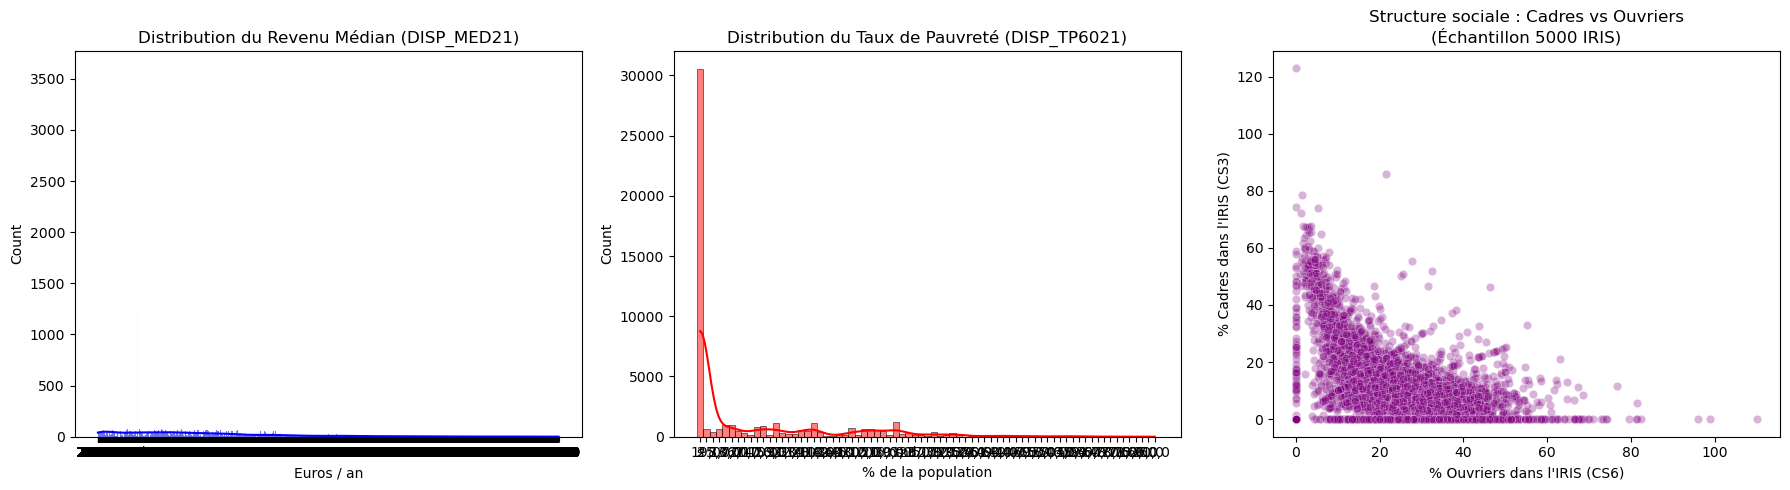

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de l'affichage pour Pandas
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# --- 1. CHEMINS DES FICHIERS ---
path_iris = "iris/"  
path_commune = "communes/"

f_dipl = os.path.join(path_iris, "base-ic-diplomes-formation-2021.CSV")
f_act = os.path.join(path_iris, "base-ic-activite-residents-2021.CSV")
f_filo_iris = os.path.join(path_iris, "BASE_TD_FILO_IRIS_2021_DISP.csv")
f_filo_com = os.path.join(path_commune, "FILO2021_DISP_COM.csv")
f_pauvres_com = os.path.join(path_commune, "FILO2021_DISP_PAUVRES_COM.csv")

def read_insee(filepath, dtype_dict=None):
    try:
        return pd.read_csv(filepath, sep=";", encoding='utf-8', dtype=dtype_dict, low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(filepath, sep=";", encoding='latin1', dtype=dtype_dict, low_memory=False)

print("⏳ Chargement des fichiers IRIS et COM...")
df_dipl = read_insee(f_dipl, {'IRIS': str, 'COM': str})
df_act = read_insee(f_act, {'IRIS': str, 'COM': str})
df_filo_iris = read_insee(f_filo_iris, {'IRIS': str})
df_filo_com = read_insee(f_filo_com, {'CODGEO': str})
df_pauvres_com = read_insee(f_pauvres_com, {'CODGEO': str})

# --- 2. PRÉPARATION DU FICHIER COMMUNE (LE BOUCHE-TROU) ---
df_com_full = pd.merge(df_filo_com, df_pauvres_com, on='CODGEO', how='left')

com_rename_map = {
    'Q221': 'DISP_MED21',
    'PACT21': 'DISP_PACT21',
    'PPAT21': 'DISP_PPAT21',
    'PPSOC21': 'DISP_PPSOC21',
    'PIMPOT21': 'DISP_PIMPOT21',
    'TP6021': 'DISP_TP6021'
}
df_com_full.rename(columns=com_rename_map, inplace=True)
cols_to_fill = list(com_rename_map.values())

for col in cols_to_fill:
    if col in df_com_full.columns and df_com_full[col].dtype == object:
        df_com_full[col] = df_com_full[col].str.replace(',', '.').replace(['nd', 'ns', 's'], np.nan)
        df_com_full[col] = pd.to_numeric(df_com_full[col], errors='coerce')

# --- 3. PRÉPARATION DU FICHIER FILOSOFI IRIS ---
filo_cols = [c for c in df_filo_iris.columns if c != 'IRIS']
for col in filo_cols:
    if df_filo_iris[col].dtype == object:
        df_filo_iris[col] = df_filo_iris[col].str.replace(',', '.').replace(['nd', 'ns', 's'], np.nan)
        df_filo_iris[col] = pd.to_numeric(df_filo_iris[col], errors='coerce')

# --- 4. FUSION GLOBALE : LA MAGIE OPÈRE ---
merged_census = pd.merge(df_dipl, df_act.drop(columns=['COM', 'TYP_IRIS', 'LAB_IRIS'], errors='ignore'), on='IRIS', how='outer')
final_db = pd.merge(merged_census, df_filo_iris, on='IRIS', how='left')
final_db = pd.merge(final_db, df_com_full[['CODGEO'] + cols_to_fill], left_on='COM', right_on='CODGEO', how='left')

for col in cols_to_fill:
    col_iris = col + "_x"
    col_com = col + "_y"
    if col_iris in final_db.columns and col_com in final_db.columns:
        final_db[col] = final_db[col_iris].fillna(final_db[col_com])
        final_db.drop(columns=[col_iris, col_com], inplace=True)

final_db.drop(columns=['CODGEO'], errors='ignore', inplace=True)

# Sauvegarde
output_path = os.path.join(path_iris, "iris_database_hybride_parfaite.csv")
final_db.to_csv(output_path, index=False)
print(f"✅ Base de données sauvegardée : '{output_path}'")



# ==============================================================================
# --- 5. AUDIT FINAL ---
# ==============================================================================
print("\n📥 Chargement pour l'Audit...")
df = pd.read_csv(output_path, dtype={'IRIS': str, 'COM': str, 'LAB_IRIS': str}, low_memory=False)

print("\n" + "="*50)
print("🔍 1. INTÉGRITÉ DE LA STRUCTURE")
print("="*50)
print(f"Nombre total de lignes (IRIS) : {len(df)}")
print(f"Nombre total de colonnes      : {len(df.columns)}")
print(f"Doublons sur le code IRIS     : {df.duplicated(subset=['IRIS']).sum()} (Doit être 0)")

if 'TYP_IRIS' in df.columns:
    print("\nRépartition par type d'IRIS (H=Habitat, A=Activité, D=Divers, Z=Non découpé) :")
    print(df['TYP_IRIS'].value_counts(dropna=False))

print("\n" + "="*50)
print("⚙️ 2. VÉRIFICATION DU TYPAGE (Text vs Numérique)")
print("="*50)

# LES BONS NOMS DE COLONNES 2021
colonnes_cles = [
    'DISP_MED21', 'DISP_PPAT21', 'DISP_TP6021', # Revenus (Filosofi)
    'C21_ACT1564_CS3', 'C21_ACT1564_CS6',       # Activité : CS3 = Cadres, CS6 = Ouvriers
    'P21_NSCOL15P_SUP5'                         # Diplômes : Sup 5
]

colonnes_presentes = []
for col in colonnes_cles:
    if col in df.columns:
        type_col = df[col].dtype
        statut = "✅ OK" if pd.api.types.is_numeric_dtype(type_col) else "❌ ERREUR (Texte)"
        print(f"{col.ljust(20)} : {str(type_col).ljust(10)} {statut}")
        colonnes_presentes.append(col)
    else:
        print(f"❌ {col} est MANQUANTE dans la base !")

print("\n" + "="*50)
print("🕳️ 3. TAUX DE COMPLÉTUDE (Le 'Bouchage de trous')")
print("="*50)
for col in colonnes_presentes:
    nb_na = df[col].isna().sum()
    pct_na = (nb_na / len(df)) * 100
    print(f"{col.ljust(20)} : {nb_na} NaN ({pct_na:.2f}%)")

print("\n" + "="*50)
print("👥 4. COHÉRENCE DÉMOGRAPHIQUE")
print("="*50)

# On utilise UNIQUEMENT les tranches d'âge mutuellement exclusives du fichier diplômes
pop_cols_strict = [
    'P21_POP0205', 'P21_POP0610', 'P21_POP1114', 
    'P21_POP1517', 'P21_POP1824', 'P21_POP2529', 'P21_POP30P'
]

# On vérifie que ces colonnes sont bien là
colonnes_presentes_pop = [c for c in pop_cols_strict if c in df.columns]

if colonnes_presentes_pop:
    # Somme propre, sans double comptage
    df['TOTAL_POP_ESTIM'] = df[colonnes_presentes_pop].sum(axis=1)
    pop_totale = df['TOTAL_POP_ESTIM'].sum()
    
    print(f"Population totale estimée (2 ans et +)  : {pop_totale:,.0f} habitants")
    
    if 'DISP_MED21' in df.columns:
        pop_avec_revenu = df[df['DISP_MED21'].notna()]['TOTAL_POP_ESTIM'].sum()
        print(f"Population couverte par les revenus     : {pop_avec_revenu:,.0f} habitants")
        print(f"Taux de couverture démographique        : {(pop_avec_revenu / pop_totale)*100:.2f}%")
else:
    print("❌ Colonnes de population introuvables pour le calcul.")
    
print("\n" + "="*50)
print("📊 5. STATISTIQUES DESCRIPTIVES")
print("="*50)
if colonnes_presentes:
    stats_df = df[colonnes_presentes].describe().T
    print(stats_df[['min', '25%', '50%', 'mean', '75%', 'max']])

# --- 6. VISUALISATION DES DISTRIBUTIONS ---
print("\n🎨 Génération des graphiques de distribution...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphique 1 : Distribution des revenus
if 'DISP_MED21' in df.columns:
    sns.histplot(df['DISP_MED21'].dropna(), bins=50, ax=axes[0], color='blue', kde=True)
    axes[0].set_title('Distribution du Revenu Médian (DISP_MED21)')
    axes[0].set_xlabel('Euros / an')

# Graphique 2 : Taux de pauvreté
if 'DISP_TP6021' in df.columns:
    sns.histplot(df['DISP_TP6021'].dropna(), bins=50, ax=axes[1], color='red', kde=True)
    axes[1].set_title('Distribution du Taux de Pauvreté (DISP_TP6021)')
    axes[1].set_xlabel('% de la population')

# Graphique 3 : Relation Cadres vs Ouvriers
if all(c in df.columns for c in ['C21_ACT1564_CS3', 'C21_ACT1564_CS6', 'P21_ACT1564']):
    # Calcul des pourcentages avec les bons noms de colonnes (CS3 = Cadres, CS6 = Ouvriers)
    df['pct_cadres'] = (df['C21_ACT1564_CS3'] / df['P21_ACT1564']) * 100
    df['pct_ouvriers'] = (df['C21_ACT1564_CS6'] / df['P21_ACT1564']) * 100
    
    sample_df = df.dropna(subset=['pct_cadres', 'pct_ouvriers']).sample(n=min(5000, len(df)), random_state=42)
    sns.scatterplot(data=sample_df, x='pct_ouvriers', y='pct_cadres', alpha=0.3, ax=axes[2], color='purple')
    axes[2].set_title('Structure sociale : Cadres vs Ouvriers\n(Échantillon 5000 IRIS)')
    axes[2].set_xlabel('% Ouvriers dans l\'IRIS (CS6)')
    axes[2].set_ylabel('% Cadres dans l\'IRIS (CS3)')

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
import os

# --- 1. CONFIGURATION DES CHEMINS ---
path_iris = "iris/"  
path_commune = "communes/"

meta_files = [
    os.path.join(path_iris, "meta_base-ic-diplomes-formation-2021.CSV"),
    os.path.join(path_iris, "meta_base-ic-activite-residents-2021.CSV"),
    os.path.join(path_iris, "meta_BASE_TD_FILO_IRIS_2021_DISP.csv"),
    os.path.join(path_commune, "meta_FILO2021_DISP_COM.csv"),
    os.path.join(path_commune, "meta_FILO2021_DISP_PAUVRES_COM.csv")
]

# --- 2. CRÉATION DU DICTIONNAIRE DE TRADUCTION ---
print("📚 Chargement et compilation des métadonnées...")
dict_meta = {}

for f in meta_files:
    if os.path.exists(f):
        try:
            df_meta = pd.read_csv(f, sep=";", encoding='utf-8')
        except UnicodeDecodeError:
            df_meta = pd.read_csv(f, sep=";", encoding='latin1')
        
        # Mapping du Code Variable vers son Libellé Long
        for _, row in df_meta.iterrows():
            if 'COD_VAR' in row and 'LIB_VAR_LONG' in row:
                # Si la variable vient de la commune, on map l'ancien nom et le nouveau
                dict_meta[row['COD_VAR']] = str(row['LIB_VAR_LONG']).strip()

# Ajout manuel des traductions pour les colonnes renommées pendant le merge hybride
dict_meta['DISP_MED21'] = "Médiane du revenu disponible par unité de consommation"
dict_meta['DISP_PPAT21'] = "Part dans le revenu disponible du patrimoine et autres revenus"
dict_meta['DISP_PPSOC21'] = "Part dans le revenu disponible des prestations sociales"
dict_meta['DISP_TP6021'] = "Taux de pauvreté au seuil de 60 %"
dict_meta['C21_ACT1564_CS3'] = "Population active - Cadres et professions intellectuelles supérieures"
dict_meta['C21_ACT1564_CS6'] = "Population active - Ouvriers"


# --- 3. ANALYSE DE LA BASE HYBRIDE ---
print("🔍 Analyse des valeurs manquantes dans 'iris_database_hybride_parfaite.csv'...\n")
df = pd.read_csv(os.path.join(path_iris, "iris_database_hybride_parfaite.csv"), low_memory=False)

total_rows = len(df)
results = []

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]) and col not in ['IRIS', 'COM']:
        nb_na = df[col].isna().sum()
        pct_na = (nb_na / total_rows) * 100
        libelle = dict_meta.get(col, "Libellé inconnu dans les métadonnées")
        results.append({'Variable': col, '% Manquant': pct_na, 'Description': libelle})

df_report = pd.DataFrame(results).sort_values(by='% Manquant')

# --- 4. AFFICHAGE DES RÉSULTATS PAR "PALIERS DE SECRET" ---
def afficher_palier(df_palier, titre):
    print("="*80)
    print(titre)
    print("="*80)
    for _, row in df_palier.iterrows():
        print(f"[{row['% Manquant']:05.2f}%] {row['Variable'].ljust(18)} : {row['Description'][:55]}...")
    print("\n")

afficher_palier(df_report[df_report['% Manquant'] < 1], 
                "🟢 PALIER 1 : DONNÉES TOTALEMENT DISPONIBLES (< 1% de vide)")

afficher_palier(df_report[(df_report['% Manquant'] >= 1) & (df_report['% Manquant'] < 20)], 
                "🟡 PALIER 2 : DONNÉES GLOBALEMENT DISPONIBLES (Revenus de base)")

afficher_palier(df_report[df_report['% Manquant'] >= 20], 
                "🔴 PALIER 3 : DONNÉES CENSURÉES PAR LE SECRET STATISTIQUE (> 20% de vide)")

📚 Chargement et compilation des métadonnées...
🔍 Analyse des valeurs manquantes dans 'iris_database_hybride_parfaite.csv'...

🟢 PALIER 1 : DONNÉES TOTALEMENT DISPONIBLES (< 1% de vide)
[00.00%] P21_POP0205        : Nombre de personnes de 2 à 5 ans...
[00.00%] P21_POP0610        : Nombre de personnes de 6 à 10 ans...
[00.00%] P21_POP1114        : Nombre de personnes de 11 à 14 ans...
[00.00%] P21_POP1517        : Nombre de personnes de 15 à 17 ans...
[00.00%] P21_POP1824        : Nombre de personnes de 18 à 24 ans...
[00.00%] P21_POP2529        : Nombre de personnes de 25 à 29 ans...
[00.00%] P21_POP30P         : Nombre de personnes de 30 ans ou plus...
[00.00%] P21_SCOL0205       : Nombre de personnes scolarisées de 2 à 5 ans...
[00.00%] P21_SCOL0610       : Nombre de personnes scolarisées de 6 à 10 ans...
[00.00%] P21_SCOL1114       : Nombre de personnes scolarisées de 11 à 14 ans...
[00.00%] P21_SCOL1517       : Nombre de personnes scolarisées de 15 à 17 ans...
[00.00%] P21_SCOL1824 

📥 Chargement de la base de données...
⚙️ Préparation des variables prédictives...

🚀 ENTRAÎNEMENT POUR 28 VARIABLES CENSURÉES
   CRITÈRES D'ACCEPTATION : R² > 73%  |  Corrélation > 0.80  |  Erreur Rel. < 25.0%

📊 BILAN DÉTAILLÉ DES IMPUTATIONS PAR MACHINE LEARNING :

         Code                                         Nom de la Variable  R² (%)  Corr. (r)  Err. Rel. (%)    Statut  Trous Bouchés
    DISP_D421 4ᵉ décile du revenu disponible par unité de consommatio...    99.4       1.00            1.3 ✅ Accepté          34790
    DISP_D621 6ᵉ décile du revenu disponible par unité de consommatio...    99.3       1.00            1.4 ✅ Accepté          34790
    DISP_D721 7ᵉ décile du revenu disponible par unité de consommatio...    98.7       0.99            2.2 ✅ Accepté          34790
    DISP_D321 3ᵉ décile du revenu disponible par unité de consommatio...    98.4       0.99            2.2 ✅ Accepté          34790
    DISP_Q321 3ᵉ quartile du revenu disponible par unité de consommat...

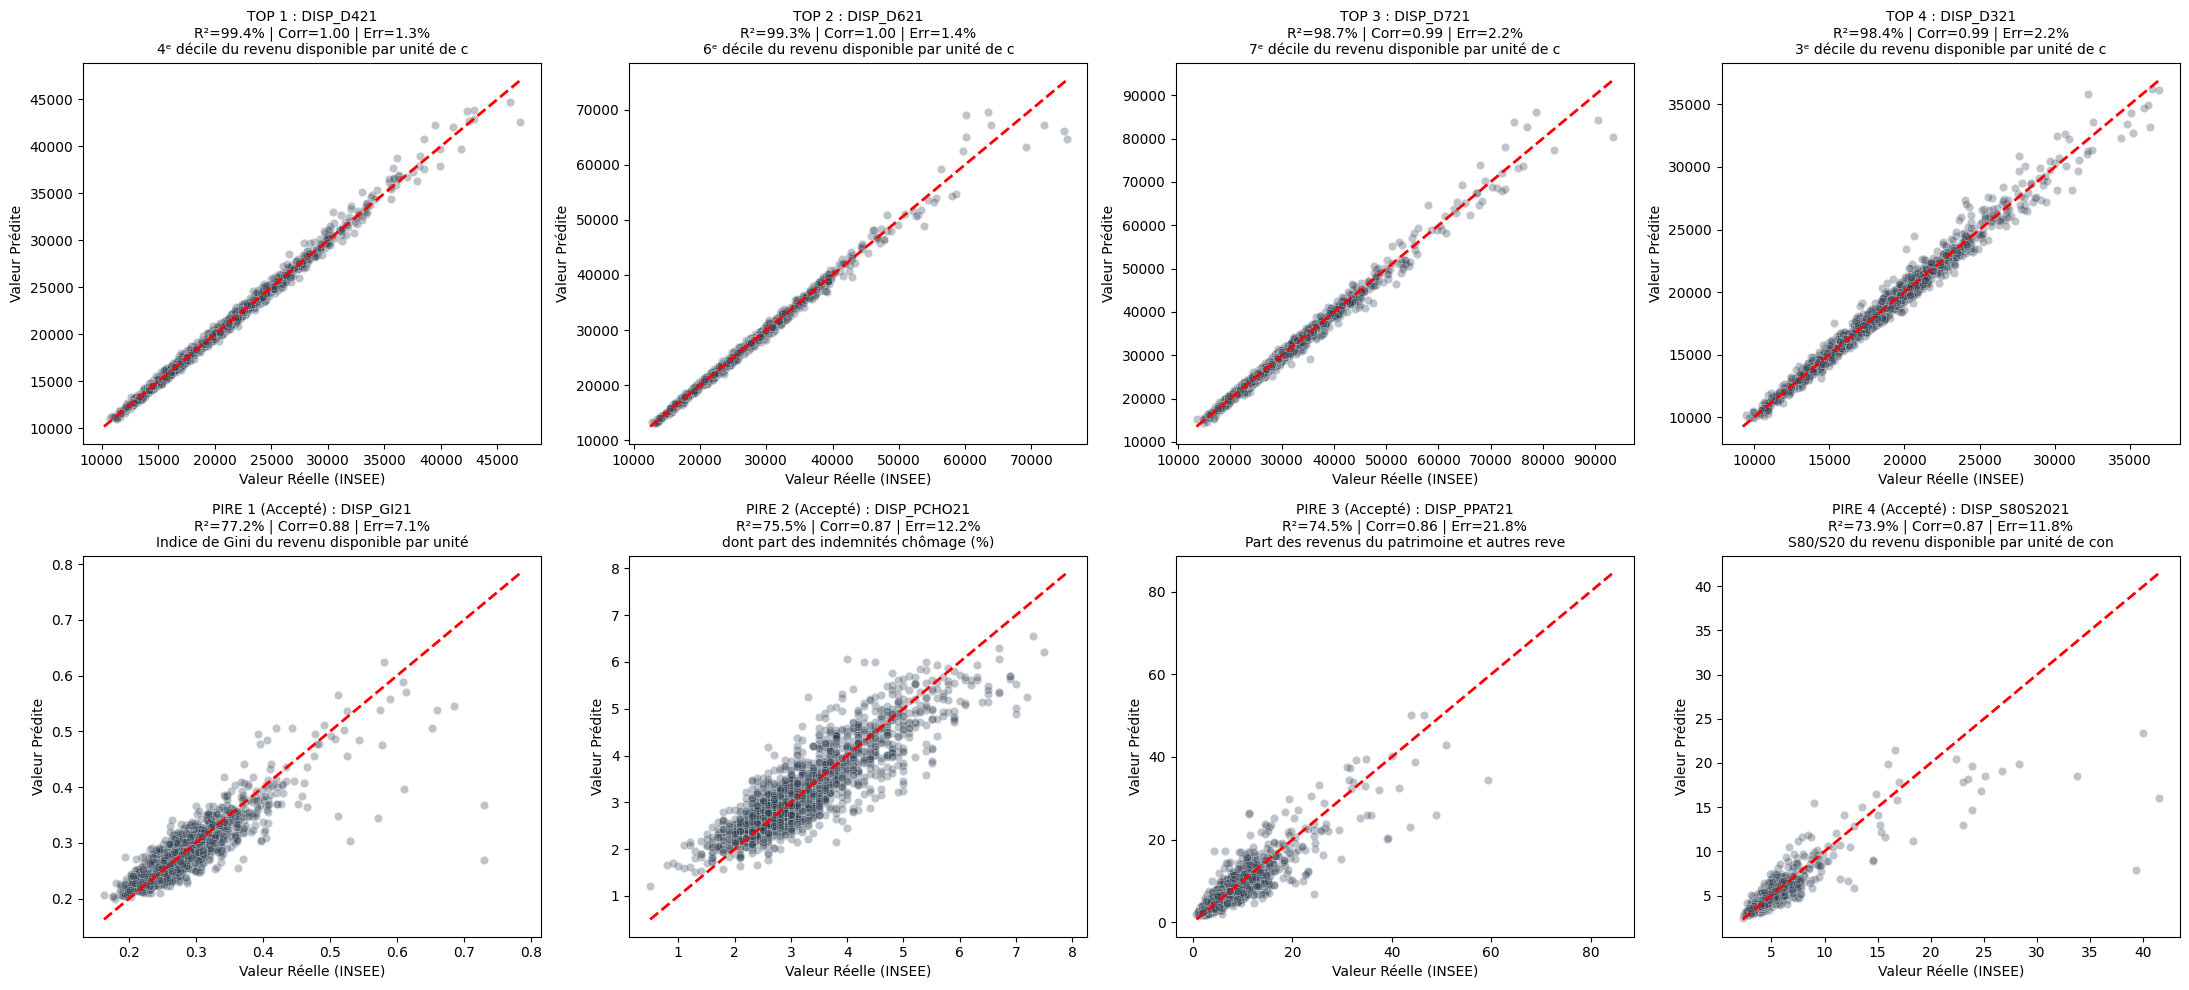


🎉 OPÉRATION SÉCURISÉE TERMINÉE ! Données sauvegardées dans : 'iris/iris_database_machine_learning.csv'


In [10]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# --- 1. CHARGEMENT DES MÉTADONNÉES ---
path_iris = "iris/"  
path_commune = "communes/"
meta_files = [
    os.path.join(path_iris, "meta_base-ic-diplomes-formation-2021.CSV"),
    os.path.join(path_iris, "meta_base-ic-activite-residents-2021.CSV"),
    os.path.join(path_iris, "meta_BASE_TD_FILO_IRIS_2021_DISP.csv")
]

dico_variables = {
    'DISP_MED21': "Médiane du revenu disponible par UC (€)",
    'DISP_PPAT21': "Part des revenus du patrimoine (%)",
    'DISP_PPSOC21': "Part des prestations sociales (%)",
    'DISP_TP6021': "Taux de pauvreté au seuil de 60 %",
    'DISP_PACT21': "Part des revenus d'activité (%)",
    'DISP_PIMPOT21': "Part des impôts (%)"
}

for f in meta_files:
    if os.path.exists(f):
        try:
            df_meta = pd.read_csv(f, sep=";", encoding='utf-8')
        except UnicodeDecodeError:
            df_meta = pd.read_csv(f, sep=";", encoding='latin1')
        for _, row in df_meta.iterrows():
            if 'COD_VAR' in row and 'LIB_VAR_LONG' in row:
                dico_variables[row['COD_VAR']] = str(row['LIB_VAR_LONG']).strip()

# --- 2. CHARGEMENT ET PRÉPARATION DE LA BASE ---
print("📥 Chargement de la base de données...")
df = pd.read_csv(os.path.join(path_iris, "iris_database_hybride_parfaite.csv"), low_memory=False)
df_imputed = df.copy()

print("⚙️ Préparation des variables prédictives...")
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
df_num = df.select_dtypes(include=numerics).copy()

if 'P21_ACT1564' in df_num.columns:
    cols_pcs = [c for c in df_num.columns if c.startswith('C21_ACT1564_CS')]
    for c in cols_pcs:
        df_num[f"PCT_{c}"] = (df_num[c] / df_num['P21_ACT1564']) * 100
        
if 'P21_POP1564' in df_num.columns:
    cols_dipl = [c for c in df_num.columns if c.startswith('P21_NSCOL15P')]
    for c in cols_dipl:
        df_num[f"PCT_{c}"] = (df_num[c] / df_num['P21_POP1564']) * 100

df_num = df_num.replace([np.inf, -np.inf], np.nan)

# --- 3. DÉTECTION DES CIBLES ET CORRECTION DE LA FUITE DE DONNÉES ---
missing_pct = (df_num.isna().sum() / len(df_num)) * 100
vars_cibles = missing_pct[(missing_pct > 10) & (missing_pct.index.str.startswith('DISP_'))].index.tolist()

cols_a_exclure = [c for c in df_num.columns if c.startswith('DISP_') and c != 'DISP_MED21']
X_cols = [c for c in df_num.columns if c not in vars_cibles and c not in cols_a_exclure]

print("\n" + "="*80)
print(f"🚀 ENTRAÎNEMENT POUR {len(vars_cibles)} VARIABLES CENSURÉES")
r2_threshold = 0.73
corr_threshold = 0.8
err_rel_threshold = 25.0
print(f"   CRITÈRES D'ACCEPTATION : R² > {r2_threshold*100:.0f}%  |  Corrélation > {corr_threshold:.2f}  |  Erreur Rel. < {err_rel_threshold:.1f}%")
print("="*80)

rapport_ml = []
plot_data = [] # Uniquement pour les modèles acceptés

for cible in vars_cibles:
    mask_known = df_num[cible].notna()
    mask_unknown = df_num[cible].isna()
    
    if mask_unknown.sum() == 0:
        continue
        
    X = df_num[X_cols]
    y = df_num[cible]
    
    # Évaluation stricte
    X_train, X_test, y_train, y_test = train_test_split(X[mask_known], y[mask_known], test_size=0.2, random_state=42)
    
    model = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=12, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred_test = model.predict(X_test)
    
    # --- CALCUL DES MÉTRIQUES ---
    r2 = r2_score(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    moyenne_cible = y_test.mean()
    
    # Corrélation de Pearson (r)
    corr = np.corrcoef(y_test, y_pred_test)[0, 1] if np.std(y_pred_test) > 0 else 0
    
    # Erreur relative globale (%)
    erreur_relative = (mae / moyenne_cible) * 100 if moyenne_cible != 0 else np.nan
    
    statut = "❌ Rejeté"
    trous_bouches = 0
    
    # --- TRIPLE VALIDATION ---
    if r2 > r2_threshold and corr > corr_threshold and erreur_relative < err_rel_threshold:
        statut = "✅ Accepté"
        trous_bouches = mask_unknown.sum()
        df_imputed.loc[mask_unknown, cible] = model.predict(X[mask_unknown])
        
        # On sauvegarde pour les graphiques SEULEMENT si c'est accepté
        plot_data.append({
            'cible': cible, 
            'nom': dico_variables.get(cible, cible)[:45],
            'r2': r2, 
            'corr': corr,
            'err_rel': erreur_relative,
            'y_test': y_test, 
            'y_pred': y_pred_test
        })
        
    rapport_ml.append({
        'Code': cible,
        'Nom de la Variable': dico_variables.get(cible, cible)[:55] + "...",
        'R² (%)': round(r2 * 100, 1),
        'Corr. (r)': round(corr, 2),
        'Err. Rel. (%)': round(erreur_relative, 1),
        'Statut': statut,
        'Trous Bouchés': trous_bouches
    })

# --- 4. AFFICHAGE DU RAPPORT FINAL ---
df_rapport = pd.DataFrame(rapport_ml).sort_values(by='R² (%)', ascending=False)
print("\n📊 BILAN DÉTAILLÉ DES IMPUTATIONS PAR MACHINE LEARNING :\n")
print(df_rapport.to_string(index=False))

# --- 5. VISUALISATION (TOP 4 vs FLOP 4 DES VARIABLES ACCEPTÉES) ---
# On trie les variables acceptées par score R2
plot_data_sorted = sorted(plot_data, key=lambda x: x['r2'], reverse=True)

if len(plot_data_sorted) >= 2: # S'il y en a au moins quelques-unes d'acceptées
    print("\n🎨 Génération des graphiques (Top 4 et Pires 4 parmi les acceptées)...")
    
    # On isole les meilleures et les moins bonnes
    top_4 = plot_data_sorted[:4]
    flop_4 = plot_data_sorted[-4:] if len(plot_data_sorted) >= 8 else plot_data_sorted[len(top_4):]
    variables_a_tracer = top_4 + flop_4
    
    # Création dynamique de la grille (2 lignes, jusqu'à 4 colonnes max)
    cols = 4 if len(variables_a_tracer) >= 4 else len(variables_a_tracer)
    lignes = 2 if len(variables_a_tracer) > 4 else 1
    
    fig, axes = plt.subplots(lignes, cols, figsize=(5.5 * cols, 5 * lignes))
    if type(axes) is not np.ndarray: axes = [axes] # Sécurité si 1 seul graph
    axes = np.array(axes).flatten()
    
    for i, data in enumerate(variables_a_tracer):
        ax = axes[i]
        sample_size = min(1500, len(data['y_test']))
        idx = np.random.choice(len(data['y_test']), sample_size, replace=False)
        
        sns.scatterplot(x=data['y_test'].iloc[idx], y=data['y_pred'][idx], alpha=0.3, color='#2c3e50', ax=ax, edgecolor='w')
        
        # Ligne d'égalité
        min_val = min(data['y_test'].min(), data['y_pred'].min())
        max_val = max(data['y_test'].max(), data['y_pred'].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
        
        titre_haut = f"TOP {i+1}" if i < len(top_4) else f"PIRE {i-len(top_4)+1} (Accepté)"
        ax.set_title(f"{titre_haut} : {data['cible']}\nR²={data['r2']*100:.1f}% | Corr={data['corr']:.2f} | Err={data['err_rel']:.1f}%\n{data['nom']}", fontsize=10)
        ax.set_xlabel('Valeur Réelle (INSEE)')
        ax.set_ylabel('Valeur Prédite')

    plt.tight_layout()
    plt.show()

# --- 6. SAUVEGARDE ---
output_path = os.path.join(path_iris, "iris_database_machine_learning.csv")
df_imputed.to_csv(output_path, index=False)
print("\n" + "="*80)
print(f"🎉 OPÉRATION SÉCURISÉE TERMINÉE ! Données sauvegardées dans : '{output_path}'")
print("="*80)


📊 IMPACT RÉEL DU SECRET STATISTIQUE (Hybride Parfaite)
Population totale estimée de la base : 66,012,880 habitants

--- Part du Patrimoine (DISP_PPAT21) ---
❌ Quartiers/Villages censurés : 60.5% des lignes
👥 POPULATION RÉELLE CENSURÉE  : 23.7% des Français (15,650,092 hab.)
✅ POPULATION BIEN DOCUMENTÉE  : 76.3% des Français (50,362,788 hab.)

--- Taux de Pauvreté (DISP_TP6021) ---
❌ Quartiers/Villages censurés : 62.4% des lignes
👥 POPULATION RÉELLE CENSURÉE  : 27.3% des Français (18,048,664 hab.)
✅ POPULATION BIEN DOCUMENTÉE  : 72.7% des Français (47,964,216 hab.)

--- Revenu Médian (DISP_MED21) ---
❌ Quartiers/Villages censurés : 7.8% des lignes
👥 POPULATION RÉELLE CENSURÉE  : 1.4% des Français (894,420 hab.)
✅ POPULATION BIEN DOCUMENTÉE  : 98.6% des Français (65,118,460 hab.)

📊 IMPACT RÉEL DU SECRET STATISTIQUE (Machine Learning)
Population totale estimée de la base : 66,012,880 habitants

--- Part du Patrimoine (DISP_PPAT21) ---
❌ Quartiers/Villages censurés : 0.0% des lignes
👥 POP

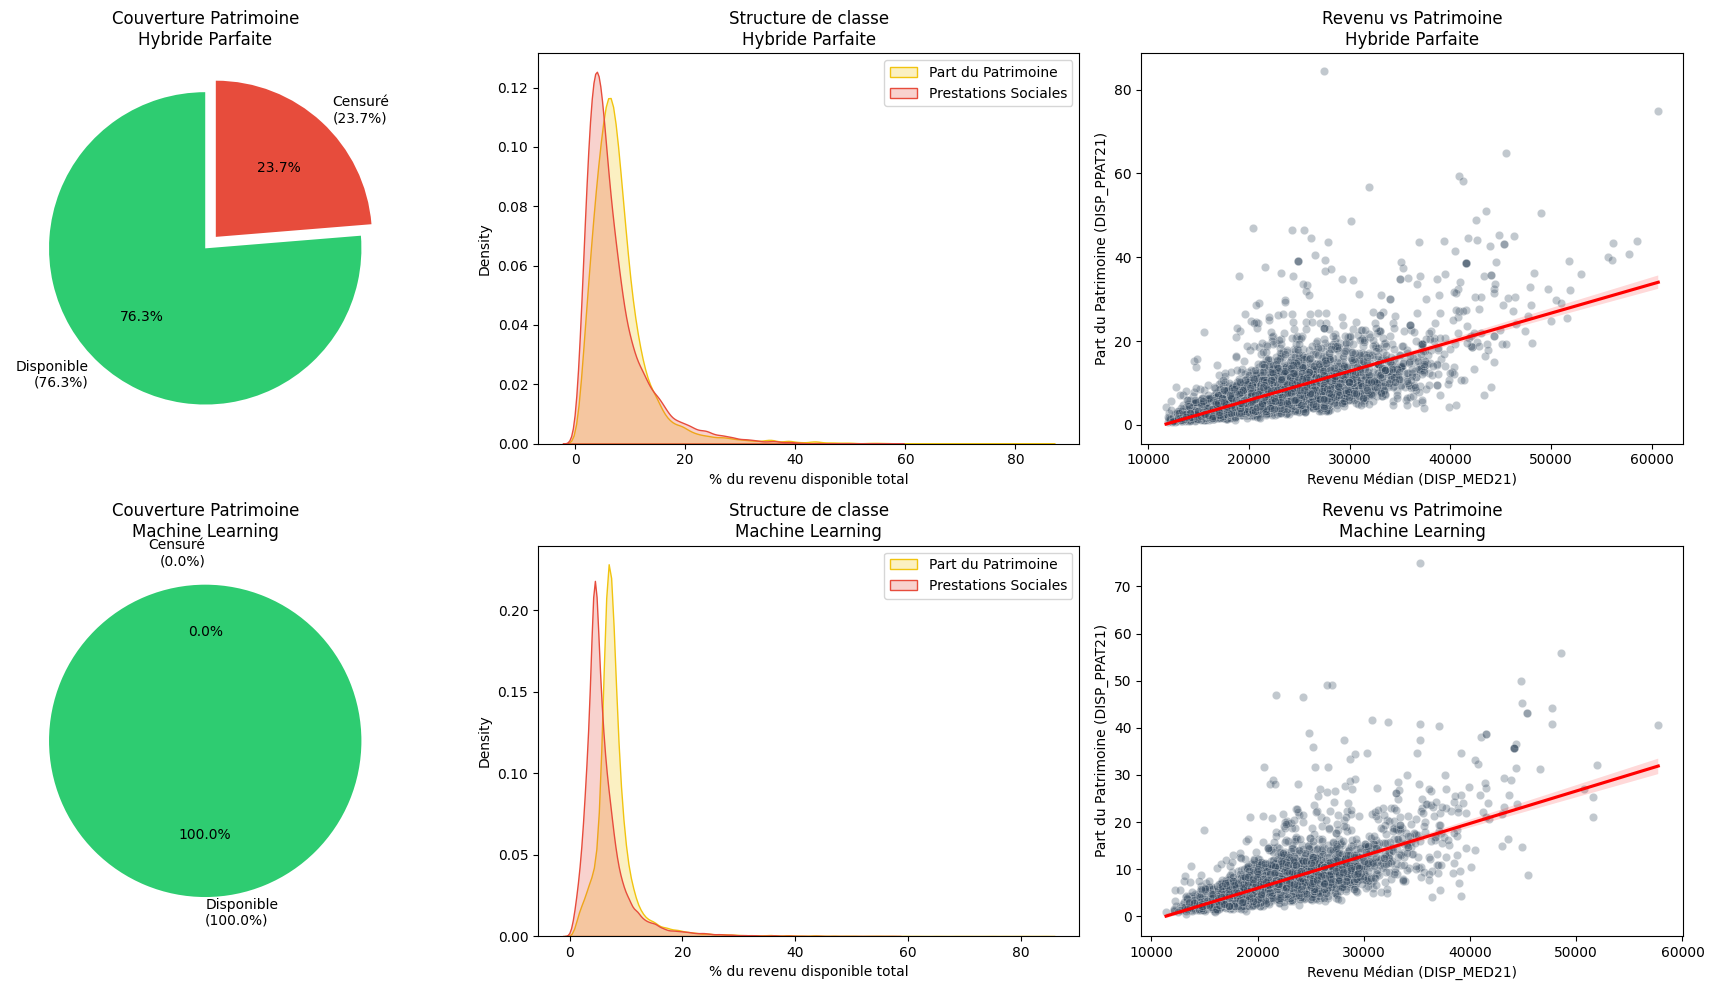

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. CHARGEMENT DES DEUX VERSIONS ---
path_iris = "iris/"
df_parfaite = pd.read_csv(os.path.join(path_iris, "iris_database_hybride_parfaite.csv"), low_memory=False)
df_ml = pd.read_csv(os.path.join(path_iris, "iris_database_machine_learning.csv"), low_memory=False)

pop_cols_strict = [
    'P21_POP0205', 'P21_POP0610', 'P21_POP1114', 
    'P21_POP1517', 'P21_POP1824', 'P21_POP2529', 'P21_POP30P'
]

# --- 2. FONCTION D'ANALYSE ---
def analyze_database(df, title_suffix):
    colonnes_presentes_pop = [c for c in pop_cols_strict if c in df.columns]
    
    if colonnes_presentes_pop:
        df['TOTAL_POP_ESTIM'] = df[colonnes_presentes_pop].sum(axis=1)
        total_pop = df['TOTAL_POP_ESTIM'].sum()
    else:
        total_pop = df['TOTAL_POP_ESTIM'].sum()
    
    variables_p3 = {
        'DISP_PPAT21': "Part du Patrimoine",
        'DISP_TP6021': "Taux de Pauvreté",
        'DISP_MED21': "Revenu Médian"
    }
    
    print("="*60)
    print(f"📊 {title_suffix}")
    print("="*60)
    print(f"Population totale estimée de la base : {total_pop:,.0f} habitants\n")
    
    for var_code, var_name in variables_p3.items():
        if var_code in df.columns:
            nb_iris_missing = df[var_code].isna().sum()
            pct_iris_missing = (nb_iris_missing / len(df)) * 100
            
            pop_available = df[df[var_code].notna()]['TOTAL_POP_ESTIM'].sum()
            pop_missing = total_pop - pop_available
            pct_pop_missing = (pop_missing / total_pop) * 100
            
            print(f"--- {var_name} ({var_code}) ---")
            print(f"❌ Quartiers/Villages censurés : {pct_iris_missing:.1f}% des lignes")
            print(f"👥 POPULATION RÉELLE CENSURÉE  : {pct_pop_missing:.1f}% des Français ({pop_missing:,.0f} hab.)")
            print(f"✅ POPULATION BIEN DOCUMENTÉE  : {100 - pct_pop_missing:.1f}% des Français ({pop_available:,.0f} hab.)\n")

# --- 3. EXÉCUTER L'ANALYSE POUR LES DEUX VERSIONS ---
analyze_database(df_parfaite, "IMPACT RÉEL DU SECRET STATISTIQUE (Hybride Parfaite)")
analyze_database(df_ml, "IMPACT RÉEL DU SECRET STATISTIQUE (Machine Learning)")

# --- 4. VISUALISATION COMPARATIVE ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (df, title) in enumerate([(df_parfaite, "Hybride Parfaite"), (df_ml, "Machine Learning")]):
    df_copy = df.copy()
    colonnes_presentes_pop = [c for c in pop_cols_strict if c in df_copy.columns]
    if colonnes_presentes_pop:
        df_copy['TOTAL_POP_ESTIM'] = df_copy[colonnes_presentes_pop].sum(axis=1)
    
    total_pop = df_copy['TOTAL_POP_ESTIM'].sum()
    
    # Graphique 1 : Camembert
    pop_av = df_copy[df_copy['DISP_PPAT21'].notna()]['TOTAL_POP_ESTIM'].sum()
    pop_miss = total_pop - pop_av
    axes[idx, 0].pie([pop_av, pop_miss], 
                labels=[f"Disponible\n({pop_av/total_pop:.1%})", f"Censuré\n({pop_miss/total_pop:.1%})"], 
                autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.1))
    axes[idx, 0].set_title(f'Couverture Patrimoine\n{title}')
    
    # Graphique 2 : Distribution
    if 'DISP_PPAT21' in df_copy.columns and 'DISP_PPSOC21' in df_copy.columns:
        sns.kdeplot(df_copy['DISP_PPAT21'].dropna(), ax=axes[idx, 1], color='#f1c40f', fill=True, label="Part du Patrimoine")
        sns.kdeplot(df_copy['DISP_PPSOC21'].dropna(), ax=axes[idx, 1], color='#e74c3c', fill=True, label="Prestations Sociales")
        axes[idx, 1].set_title(f'Structure de classe\n{title}')
        axes[idx, 1].set_xlabel('% du revenu disponible total')
        axes[idx, 1].legend()
    
    # Graphique 3 : Corrélation
    if 'DISP_MED21' in df_copy.columns and 'DISP_PPAT21' in df_copy.columns:
        sample_df = df_copy.dropna(subset=['DISP_MED21', 'DISP_PPAT21']).sample(n=min(5000, len(df_copy)), random_state=42)
        sns.scatterplot(data=sample_df, x='DISP_MED21', y='DISP_PPAT21', alpha=0.3, color='#34495e', ax=axes[idx, 2])
        sns.regplot(data=sample_df, x='DISP_MED21', y='DISP_PPAT21', scatter=False, ax=axes[idx, 2], color='red')
        axes[idx, 2].set_title(f'Revenu vs Patrimoine\n{title}')
        axes[idx, 2].set_xlabel('Revenu Médian (DISP_MED21)')
        axes[idx, 2].set_ylabel('Part du Patrimoine (DISP_PPAT21)')

plt.tight_layout()
plt.show()

In [52]:
import pandas as pd
import numpy as np
import os

path_iris = "iris/"

# --- 1. Charger la base ML (49 280 IRIS) ---
print("Chargement iris_database_machine_learning.csv...")
df_socio = pd.read_csv(
    os.path.join(path_iris, "iris_database_machine_learning.csv"),
    dtype={'IRIS': str, 'COM': str},
    low_memory=False
)
print(f"Base ML : {len(df_socio)} IRIS x {len(df_socio.columns)} colonnes")

# --- 2. Charger base-ic-evol-struct-pop-2020.CSV ---
print("Chargement base-ic-evol-struct-pop-2020.CSV...")
df_pop = pd.read_csv(
    os.path.join(path_iris, "base-ic-evol-struct-pop-2020.CSV"),
    sep=';',
    dtype={'IRIS': str, 'COM': str},
    low_memory=False
)
df_pop['IRIS'] = df_pop['IRIS'].astype(str).str.zfill(9)
print(f"Population 2020 : {len(df_pop)} IRIS")

# --- 3. Calculer les variables demographiques (formules identiques a template_merge_iris_bv/utils.py) ---
AGE_MAP = {
    "P20_POP0002": 1,  "P20_POP0305": 4,  "P20_POP0610": 8,
    "P20_POP1117": 14, "P20_POP1824": 21, "P20_POP2539": 32,
    "P20_POP4054": 47, "P20_POP5564": 60, "P20_POP6579": 72, "P20_POP80P": 90
}
CSP_MAPPING = {
    "pct_csp_agriculteur":   "C20_POP15P_CS1",
    "pct_csp_independant":   "C20_POP15P_CS2",
    "pct_csp_plus":          "C20_POP15P_CS3",
    "pct_csp_intermediaire": "C20_POP15P_CS4",
    "pct_csp_employe":       "C20_POP15P_CS5",
    "pct_csp_ouvrier":       "C20_POP15P_CS6",
    "pct_csp_retraite":      "C20_POP15P_CS7",
    "pct_csp_sans_emploi":   "C20_POP15P_CS8",
}

pop = df_pop['P20_POP'].replace(0, np.nan)
pop15 = df_pop['C20_POP15P'].replace(0, np.nan)

# Age moyen pondeere
df_pop['age_moyen']     = sum(age * df_pop[col] for col, age in AGE_MAP.items()) / pop
df_pop['pop_totale']    = df_pop['P20_POP']
# NOTE: utils.py utilisait P20_F* (femmes seulement) pour ces 3 variables — bug corrige ici
df_pop['pct_0_19']      = df_pop['P20_POP0019'] / pop * 100
df_pop['pct_20_64']     = df_pop['P20_POP2064'] / pop * 100
df_pop['pct_65_plus']   = df_pop['P20_POP65P']  / pop * 100
df_pop['pct_etrangers'] = df_pop['P20_POP_ETR'] / pop * 100
df_pop['pct_immigres']  = df_pop['P20_POP_IMM'] / pop * 100
for col_out, col_in in CSP_MAPPING.items():
    df_pop[col_out] = df_pop[col_in] / pop15 * 100

# --- 4. Nouvelles variables calculees ---
pop_h15 = df_pop['C20_H15P'].replace(0, np.nan)
pop_f15 = df_pop['C20_F15P'].replace(0, np.nan)
df_pop['pct_femmes']        = df_pop['P20_POPF'] / pop * 100
df_pop['taille_menage_moy'] = df_pop['P20_POP'] / df_pop['P20_PMEN'].replace(0, np.nan)
df_pop['pct_hors_menage']   = df_pop['P20_PHORMEN'] / pop * 100
df_pop['ecart_csp_plus_hf'] = (df_pop['C20_H15P_CS3'] / pop_h15 - df_pop['C20_F15P_CS3'] / pop_f15) * 100

# --- 5. Colonnes a inclure dans le CSV final ---
# Variables calculees (pct_* etc.) + toutes les colonnes brutes P20_*/C20_*
cols_calculees = [
    'IRIS',
    'pop_totale', 'age_moyen',
    'pct_0_19', 'pct_20_64', 'pct_65_plus',
    'pct_etrangers', 'pct_immigres',
    'pct_csp_agriculteur', 'pct_csp_independant', 'pct_csp_plus',
    'pct_csp_intermediaire', 'pct_csp_employe', 'pct_csp_ouvrier',
    'pct_csp_retraite', 'pct_csp_sans_emploi',
    'pct_femmes', 'taille_menage_moy', 'pct_hors_menage', 'ecart_csp_plus_hf',
]
cols_brutes = [c for c in df_pop.columns if c.startswith('P20_') or c.startswith('C20_')]
df_demo = df_pop[cols_calculees + cols_brutes].copy()

# --- 6. Charger nom_commune depuis COG 2026 ---
print("Chargement noms de communes (COG 2026)...")
df_cog = pd.read_csv(
    "cog_ensemble_2026_csv/v_commune_2026.csv",
    dtype={'COM': str},
    usecols=['COM', 'LIBELLE']
).rename(columns={'LIBELLE': 'nom_commune'})
df_cog['COM'] = df_cog['COM'].str.zfill(5)

# --- 7. Fusion principale (LEFT join — conserve tous les IRIS) ---
print("Fusion ML + demographics...")
df_final = pd.merge(df_socio, df_demo, on='IRIS', how='left')

# Ajouter nom_commune via COM
df_final['_COM5'] = df_final['COM'].astype(str).str.zfill(5)
df_final = pd.merge(df_final, df_cog, left_on='_COM5', right_on='COM', how='left', suffixes=('', '_cog'))
df_final.drop(columns=['_COM5', 'COM_cog'], errors='ignore', inplace=True)

print(f"Resultat : {len(df_final)} IRIS x {len(df_final.columns)} colonnes")

# --- 8. Sauvegarde ---
output_path = os.path.join(path_iris, "iris_final_socio_politique_bis.csv")
df_final.to_csv(output_path, index=False)
print(f"Sauvegarde : {output_path}")

# --- 9. Verifications ---
print("\n=== VERIFICATIONS ===")
print(f"IRIS total : {len(df_final)} (ancien avec jolivet : 45 650 — gain : +{len(df_final)-45650})")

for col in cols_calculees:
    present = col in df_final.columns
    nan_pct = df_final[col].isna().mean() * 100 if present else 100.0
    status = "OK" if present else "MANQUANT"
    print(f"  {col:<30} [{status}] NaN: {nan_pct:.1f}%")

# Comparaison avec ancienne version jolivet
try:
    df_old = pd.read_csv(os.path.join(path_iris, "iris_final_socio_politique.csv"), low_memory=False)
    print("\n--- Comparaison medianes (nouveau vs jolivet) ---")
    print("  NOTE: pct_0_19/20_64/65_plus ~2x plus grands (bug utils.py corrige — utilisait femmes seulement)")
    for col in cols_calculees[1:]:
        if col in df_final.columns and col in df_old.columns:
            new_med = df_final[col].median()
            old_med = df_old[col].median()
            print(f"  {col}: nouveau={new_med:.2f}  jolivet={old_med:.2f}  delta={new_med-old_med:+.3f}")
except FileNotFoundError:
    print("  (iris_final_socio_politique.csv non disponible pour comparaison)")

Chargement iris_database_machine_learning.csv...


Base ML : 49280 IRIS x 186 colonnes
Chargement base-ic-evol-struct-pop-2020.CSV...
Population 2020 : 49273 IRIS
Chargement noms de communes (COG 2026)...
Fusion ML + demographics...
Resultat : 50153 IRIS x 278 colonnes
Sauvegarde : iris/iris_final_socio_politique_bis.csv

=== VERIFICATIONS ===
IRIS total : 50153 (ancien avec jolivet : 45 650 — gain : +4503)
  IRIS                           [OK] NaN: 0.0%
  pop_totale                     [OK] NaN: 0.1%
  age_moyen                      [OK] NaN: 0.3%
  pct_0_19                       [OK] NaN: 0.3%
  pct_20_64                      [OK] NaN: 0.3%
  pct_65_plus                    [OK] NaN: 0.3%
  pct_etrangers                  [OK] NaN: 0.3%
  pct_immigres                   [OK] NaN: 0.3%
  pct_csp_agriculteur            [OK] NaN: 0.4%
  pct_csp_independant            [OK] NaN: 0.4%
  pct_csp_plus                   [OK] NaN: 0.4%
  pct_csp_intermediaire          [OK] NaN: 0.4%
  pct_csp_employe                [OK] NaN: 0.4%
  pct_csp_ouvrie

In [ ]:
import geopandas as gpd
import pandas as pd
import os

# --- 1. CONFIGURATION DES CHEMINS ---
# Remplace par les vrais noms de tes fichiers
F_BUREAUX = "bureau-de-vote-insee-reu-openstreetmap.gpkg" 
F_IRIS = "contours/CONTOURS-IRIS.shp" # Le fond de carte INSEE des IRIS

print("⏳ ÉTAPE 1 : Chargement des 49 000 IRIS...")
gdf_iris = gpd.read_file(F_IRIS)

# On s'assure que le code IRIS est propre (9 caractères)
gdf_iris['CODE_IRIS'] = gdf_iris['CODE_IRIS'].astype(str).str.zfill(9)
# On ne garde que ce qui est utile pour la RAM
gdf_iris = gdf_iris[['CODE_IRIS', 'geometry']]

print("⏳ ÉTAPE 2 : Chargement des 70 000 Bureaux de Vote (Ça va prendre quelques minutes, respire...)")
gdf_bureaux = gpd.read_file(F_BUREAUX)

# On harmonise le système de coordonnées (Lambert 93 - EPSG:2154) pour que les deux cartes se superposent parfaitement
print("🗺️  Alignement des projections géographiques...")
if gdf_bureaux.crs != "EPSG:2154":
    gdf_bureaux = gdf_bureaux.to_crs("EPSG:2154")
if gdf_iris.crs != "EPSG:2154":
    gdf_iris = gdf_iris.to_crs("EPSG:2154")

# --- 2. L'ASTUCE DE JOLIVET : LE POINT CENTRAL ---
print("📍 Transformation des bureaux en points centraux (pour éviter les calculs de frontières complexes)...")
# representative_point() garantit que le point tombe DANS le polygone, contrairement au centroid
gdf_bureaux['geometry'] = gdf_bureaux.geometry.representative_point()

# --- 3. LA JOINTURE SPATIALE (LE MOMENT MAGIQUE) ---
print("🤝 Calcul des intersections géographiques (Spatial Join)...")
# On regarde dans quel IRIS tombe chaque point de bureau de vote
jointure = gpd.sjoin(gdf_bureaux, gdf_iris, how="inner", predicate="within")

# --- 4. CRÉATION DE LA CLÉ UNIQUE DU BUREAU DE VOTE ---
# Le ministère de l'Intérieur identifie un bureau par : Code_Commune + Code_Bureau
print("🔑 Création des clés uniques...")
def format_bureau_id(row):
    insee = str(row['insee']).zfill(5)
    
    # Gestion des arrondissements de Paris/Lyon/Marseille (PLM)
    bureau = str(row['bureau'])
    if bureau == 'None' or bureau == 'nan':
        bureau = "0001"
    elif "_" in bureau:
        code_postal, bureau_num = bureau.split("_")
        if insee == "75056": # Paris
            arrond = code_postal[3:6]
            bureau = arrond + bureau_num.zfill(2)
        else:
            bureau = bureau_num.zfill(4)
    else:
        bureau = bureau.zfill(4)
        
    return f"{insee}_{bureau}"

jointure['ID_BUREAU_VOTE'] = jointure.apply(format_bureau_id, axis=1)

# --- 5. NETTOYAGE ET SAUVEGARDE DE LA TABLE DE PASSAGE ---
table_passage = jointure[['ID_BUREAU_VOTE', 'CODE_IRIS']].drop_duplicates()

output_file = "table_passage_BV_IRIS.csv"
table_passage.to_csv(output_file, index=False)

print("\n" + "="*60)
print(f"🎉 BINGO ! Table de correspondance créée avec succès.")
print(f"✅ {len(table_passage)} bureaux de vote ont été rattachés à un IRIS.")
print(f"💾 Fichier sauvegardé : '{output_file}'")
print("="*60)

⏳ ÉTAPE 1 : Chargement des 49 000 IRIS...
⏳ ÉTAPE 2 : Chargement des 70 000 Bureaux de Vote (Ça va prendre quelques minutes, respire...)
🗺️  Alignement des projections géographiques...
📍 Transformation des bureaux en points centraux (pour éviter les calculs de frontières complexes)...
🤝 Calcul des intersections géographiques (Spatial Join)...
🔑 Création des clés uniques...

🎉 BINGO ! Table de correspondance créée avec succès.
✅ 66655 bureaux de vote ont été rattachés à un IRIS.
💾 Fichier sauvegardé : 'table_passage_BV_IRIS.csv' (Tu n'as plus besoin du fichier de 500 Mo !)


In [54]:
df_final = pd.read_csv(os.path.join(path_iris, "iris_final_socio_politique.csv"), low_memory=False)
df_final_bis = pd.read_csv(os.path.join(path_iris, "iris_final_socio_politique_bis.csv"), low_memory=False)
print(f"Base originale : {len(df_final)} IRIS x {len(df_final.columns)} colonnes")
print(f"Base bis : {len(df_final_bis)} IRIS x {len(df_final_bis.columns)} colonnes")

Base originale : 45650 IRIS x 218 colonnes
Base bis : 50153 IRIS x 278 colonnes


In [75]:
import pandas as pd 

EMBEDDING_VARS = [
    'pct_etrangers', 'pct_immigres', 'age_moyen', 'pct_femmes',
    'taille_menage_moy', 'pct_hors_menage', 'ecart_csp_plus_hf',
    'pct_0_19', 'pct_20_64', 'pct_65_plus',
    'pct_csp_agriculteur', 'pct_csp_independant', 'pct_csp_plus',
    'pct_csp_intermediaire', 'pct_csp_employe', 'pct_csp_ouvrier',
    'pct_csp_retraite', 'pct_csp_sans_emploi',
    'DISP_MED21', 'DISP_TP6021', 'DISP_GI21', 'DISP_RD21', 'DISP_S80S2021',
    'DISP_PTSA21', 'DISP_PPAT21', 'DISP_PPEN21', 'DISP_PPSOC21',
    'DISP_PCHO21', 'DISP_PPFAM21', 'DISP_PPLOGT21', 'DISP_PPMINI21',
    'DISP_PIMPOT21', 'DISP_PACT21',
    'pct_sup5', 'pct_sans_diplome', 'pct_capbep', 'pct_bac_plus',
    'pct_chomage', 'pct_cdi', 'pct_cdd', 'pct_interim',
    'pct_temps_partiel', 'pct_inactif', 'pct_etudiants',
    'pct_actifs_voiture', 'pct_actifs_transports', 'pct_actifs_velo',
    'pct_actifs_2roues', 'pct_actifs_marche',
    'pct_proprietaires', 'pct_locataires', 'pct_hlm', 'pct_logvac',
    'pct_maison', 'pct_appart', 'pct_petits_logements', 'pct_grands_logements',
    'pct_logements_anciens', 'pct_logements_recents',
    'pct_voiture_0', 'pct_voiture_2plus', 'surface_moyenne', 'pct_suroccupation',
    'pct_chauffage_elec', 'pct_chauffage_fioul', 'pct_chauffage_gaz_ville',
    'pct_chauffage_gaz_bouteille', 'pct_chauffage_autre',
    'pct_garage', 'nb_pieces_moyen', 'pct_studios', 'pct_logements_5p_plus',
    'bpe_total_pour1000', 'bpe_A_services_pour1000', 'bpe_B_commerces_pour1000',
    'bpe_C_enseignement_pour1000', 'bpe_D_sante_pour1000',
    'bpe_E_transports_pour1000', 'bpe_F_sports_culture_pour1000',
    'bpe_G_tourisme_pour1000', 'bpe_educ_prioritaire_pour1000',
    'bpe_ecole_privee_pour1000', 'bpe_sport_indoor_pour1000',
    'pct_sport_accessible',
]

def compute_embeddings(df):
    """Calcule les coordonnées t-SNE et UMAP sur tous les IRIS."""
    from sklearn.manifold import TSNE
    try:
        import umap
        HAS_UMAP = True
    except ImportError:
        HAS_UMAP = False
        print("  WARNING: umap-learn non installé, UMAP ignoré")

    print("\n" + "=" * 60)
    print("EMBEDDINGS : t-SNE + UMAP sur tous les IRIS")
    print("=" * 60)

    # Sélectionner les variables disponibles
    var_names = [v for v in EMBEDDING_VARS if v in df.columns]
    print(f"  {len(var_names)} variables socio disponibles sur {len(EMBEDDING_VARS)}")

    pop = df['pop_totale'].values.astype(float)
    X = df[var_names].values.astype(float)

    # Remplacer pop NaN/0 par 1 (poids minimal)
    pop = np.where(np.isfinite(pop) & (pop > 0), pop, 1.0)

    # Imputer les NaN par la médiane
    for j in range(X.shape[1]):
        col = X[:, j]
        nans = ~np.isfinite(col)
        if nans.any():
            valid_mask = np.isfinite(col)
            med = np.median(col[valid_mask]) if valid_mask.sum() > 0 else 0.0
            col[nans] = med

    # Standardisation pondérée par population
    w_norm = pop / pop.sum()
    w_means = (X * w_norm[:, None]).sum(axis=0)
    X_c = X - w_means
    w_stds = np.sqrt((X_c ** 2 * w_norm[:, None]).sum(axis=0))
    w_stds[w_stds < 1e-10] = 1e-10
    X_std = X_c / w_stds

    # PCA réduction à 20 composantes
    C = (X_std * w_norm[:, None]).T @ X_std
    eigenvalues, eigenvectors = np.linalg.eigh(C)
    idx = eigenvalues.argsort()[::-1]
    eigenvectors = eigenvectors[:, idx]
    n_pca_dims = min(20, X_std.shape[1])
    X_pca = X_std @ eigenvectors[:, :n_pca_dims]
    print(f"  PCA : réduction à {n_pca_dims} composantes")

    # t-SNE
    print("  t-SNE en cours (peut prendre quelques minutes)...")
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000,
                random_state=42, init='pca', learning_rate='auto')
    tsne_coords = tsne.fit_transform(X_pca)
    df['tsne_x'] = tsne_coords[:, 0]
    df['tsne_y'] = tsne_coords[:, 1]
    print(f"  t-SNE terminé : x=[{tsne_coords[:, 0].min():.1f}, {tsne_coords[:, 0].max():.1f}]")

    # UMAP
    if HAS_UMAP:
        print("  UMAP en cours...")
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                            random_state=42, metric='euclidean')
        umap_coords = reducer.fit_transform(X_pca)
        df['umap_x'] = umap_coords[:, 0]
        df['umap_y'] = umap_coords[:, 1]
        print(f"  UMAP terminé : x=[{umap_coords[:, 0].min():.1f}, {umap_coords[:, 0].max():.1f}]")

    return df

df = pd.read_csv(os.path.join(path_iris, "iris_final_socio_politique_bis.csv"), low_memory=False)
df_embed = compute_embeddings(df)

c:\Users\vbecquet\AppData\Local\miniconda3\envs\vadim_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



EMBEDDINGS : t-SNE + UMAP sur tous les IRIS
  84 variables socio disponibles sur 84
  PCA : réduction à 20 composantes
  t-SNE en cours (peut prendre quelques minutes)...
  t-SNE terminé : x=[-99.5, 97.8]
  UMAP en cours...


c:\Users\vbecquet\AppData\Local\miniconda3\envs\vadim_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP terminé : x=[-0.9, 13.4]


In [87]:
import numpy as np

def count_decimals(x):
    if pd.isna(x):
        return 0
    s = str(x)
    if '.' in s:
        return len(s.split('.')[1])
    return 0

numerical_cols = df_embed.select_dtypes(include=[np.number]).columns
nums = df_embed[numerical_cols].apply(lambda col: col.apply(count_decimals).max())
print(nums)

P21_POP0205                   15
P21_POP0610                   15
P21_POP1114                   15
P21_POP1517                   15
P21_POP1824                   15
                              ..
score_peripherie_metropole    16
tsne_x                        19
tsne_y                        19
umap_x                        20
umap_y                        20
Length: 456, dtype: int64


In [19]:
#Open and explore parquet file
import pandas as pd
df_results = pd.read_parquet('resultats_elections/general_results.parquet')
df_candidats = pd.read_parquet('resultats_elections/candidats_results.parquet')
df_candidats_eur2019 = df_candidats[df_candidats['id_election']=='2019_euro_t1']


In [20]:
display(df_candidats_eur2019.head())
print("Unique libelle_abrege_liste:")
print(df_candidats_eur2019.libelle_abrege_liste.unique().tolist())

# Calculate total votes per list and sort descending
vote_counts = df_candidats_eur2019.groupby('libelle_abrege_liste')['voix'].sum().sort_values(ascending=False)
print("\nTotal votes per list (sorted descending):")
print(vote_counts)

,id_election,id_brut_miom,code_departement,code_commune,code_bv,no_panneau,voix,ratio_voix_inscrits,ratio_voix_exprimes,nuance,sexe,nom,prenom,liste,libelle_abrege_liste,libelle_etendu_liste,nom_tete_liste,binome
1084386,2019_euro_t1,01001_0001,01,01001,0001,1.0,13,2.16,4.14,None,None,None,None,None,LA FRANCE INSOUMISE,None,AUBRY Manon,None
1084387,2019_euro_t1,01002_0001,01,01002,0001,1.0,6,2.86,4.44,None,None,None,None,None,LA FRANCE INSOUMISE,None,AUBRY Manon,None
1084388,2019_euro_t1,01004_0001,01,01004,0001,1.0,39,3.71,8.23,None,None,None,None,None,LA FRANCE INSOUMISE,None,AUBRY Manon,None
1084389,2019_euro_t1,01004_0002,01,01004,0002,1.0,42,3.80,7.78,None,None,None,None,None,LA FRANCE INSOUMISE,None,AUBRY Manon,None
1084390,2019_euro_t1,01004_0003,01,01004,0003,1.0,31,2.93,5.63,None,None,None,None,None,LA FRANCE INSOUMISE,None,AUBRY Manon,None


Unique libelle_abrege_liste:
['LA FRANCE INSOUMISE', 'UNE FRANCE ROYALE', 'LA LIGNE CLAIRE', 'PARTI PIRATE', 'RENAISSANCE', 'DÉMOCRATIE REPRÉSENTATIVE', 'ENSEMBLE PATRIOTES', 'PACE', 'URGENCE ÉCOLOGIE', 'LISTE DE LA RECONQUÊTE', 'LES EUROPÉENS', "ENVIE D'EUROPE", 'PARTI FED. EUROPÉEN', 'INITIATIVE CITOYENNE', 'DEBOUT LA FRANCE', 'ALLONS ENFANTS', 'DÉCROISSANCE 2019', 'LUTTE OUVRIÈRE', "POUR L'EUROPE DES GENS", 'ENSEMBLE POUR LE FREXIT', 'LISTE CITOYENNE', 'À VOIX ÉGALES', 'PRENEZ LE POUVOIR', 'NEUTRE ET ACTIF', 'RÉVOLUTIONNAIRE', 'ESPERANTO', 'ÉVOLUTION CITOYENNE', 'ALLIANCE JAUNE', 'UNION DROITE-CENTRE', 'EUROPE ÉCOLOGIE', 'PARTI ANIMALISTE', "LES OUBLIES DE L'EUROPE", 'UDLEF', 'EUROPE AU SERVICE PEUPLES']

Total votes per list (sorted descending):
libelle_abrege_liste
PRENEZ LE POUVOIR            5286939
RENAISSANCE                  5079015
EUROPE ÉCOLOGIE              3055023
UNION DROITE-CENTRE          1920407
LA FRANCE INSOUMISE          1428548
ENVIE D'EUROPE               14031

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
path_iris = "iris/"

df = pd.read_csv(os.path.join(path_iris, "iris_final_socio_politique.csv"), low_memory=False)
df_bis = pd.read_csv(os.path.join(path_iris, "iris_final_socio_politique_bis.csv"), low_memory=False)
df_hybpar = pd.read_csv(os.path.join(path_iris, "iris_database_hybride_parfaite.csv"), low_memory=False)
# df = pd.read_csv(os.path.join(path_iris, "iris_database_machine_learning.csv"), low_memory=False)
df.keys()



Index(['IRIS', 'COM', 'TYP_IRIS', 'LAB_IRIS', 'P21_POP0205', 'P21_POP0610',
       'P21_POP1114', 'P21_POP1517', 'P21_POP1824', 'P21_POP2529',
       ...
       'score_pca_4', 'score_pca_5', 'score_pca_6', 'score_pca_7',
       'score_pca_8', 'tsne_x', 'tsne_y', 'umap_x', 'umap_y', 'nom_commune'],
      dtype='str', length=462)

In [64]:
dfs = {
    "df": df,
    "df Bis": df_bis,
    "df Hybride Parfaite": df_hybpar
}
for name, df in dfs.items():
    print(f"\n=== {name} ===")
    summary = []
    DISP_cols = [col for col in df.columns if col.startswith('DISP_')]
    for col in DISP_cols:
        ser = df[col]
        dtype = ser.dtype
        n_count = (ser == 'n').sum() if ser.dtype == object else 0
        ns_count = (ser == 'ns').sum() if ser.dtype == object else 0
        nan_count = ser.isna().sum()
        other_count = len(ser) - n_count - ns_count - nan_count

        summary.append({
            'variable': col,
            'dtype': str(dtype),
            'count_n': int(n_count),
            'count_ns': int(ns_count),
            'count_nan': int(nan_count),
            'count_other': int(other_count)
        })

    summary_df = pd.DataFrame(summary)
    display(summary_df)


=== df ===


,variable,dtype,count_n,count_ns,count_nan,count_other
0,DISP_INCERT21,str,0,0,33277,16026
1,DISP_Q121,str,0,0,33277,16026
2,DISP_Q321,str,0,0,33277,16026
3,DISP_EQ21,str,0,0,33277,16026
4,DISP_D121,str,0,0,33277,16026
5,DISP_D221,str,0,0,33277,16026
6,DISP_D321,str,0,0,33277,16026
7,DISP_D421,str,0,0,33277,16026
8,DISP_D621,str,0,0,33277,16026
9,DISP_D721,str,0,0,33277,16026



=== df Bis ===


,variable,dtype,count_n,count_ns,count_nan,count_other
0,DISP_INCERT21,float64,0,0,0,49303
1,DISP_Q121,float64,0,0,0,49303
2,DISP_Q321,float64,0,0,0,49303
3,DISP_EQ21,float64,0,0,0,49303
4,DISP_D121,float64,0,0,0,49303
5,DISP_D221,float64,0,0,0,49303
6,DISP_D321,float64,0,0,0,49303
7,DISP_D421,float64,0,0,0,49303
8,DISP_D621,float64,0,0,0,49303
9,DISP_D721,float64,0,0,0,49303



=== df Hybride Parfaite ===


,variable,dtype,count_n,count_ns,count_nan,count_other
0,DISP_INCERT21,str,0,0,33277,16026
1,DISP_Q121,str,0,0,33277,16026
2,DISP_Q321,str,0,0,33277,16026
3,DISP_EQ21,str,0,0,33277,16026
4,DISP_D121,str,0,0,33277,16026
5,DISP_D221,str,0,0,33277,16026
6,DISP_D321,str,0,0,33277,16026
7,DISP_D421,str,0,0,33277,16026
8,DISP_D621,str,0,0,33277,16026
9,DISP_D721,str,0,0,33277,16026


<Axes: >

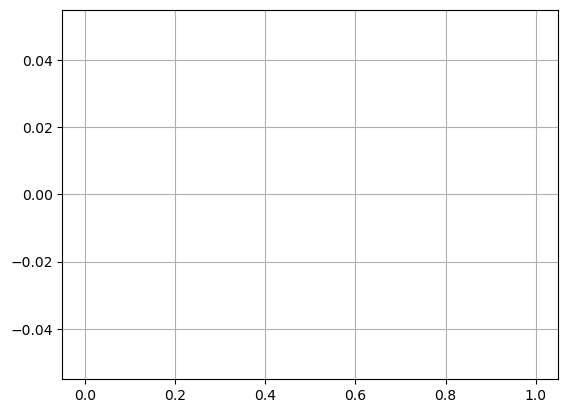

In [39]:
df['DISP_TP6021'].hist(bins=50)